# Trend Projection to 2030

This notebook projects adaptation aid forward to 2030 to illustrate where current allocation
trajectories lead. Two views are produced: a per-country linear trend, fitted on each country's
2010 to 2023 aid series and extrapolated to 2030, which feeds the application's country projection
panel; and a regional aggregate trend, which is more stable because it averages over country-level
noise and pairs with the Paris Agreement finding on regional allocation. All projections are naive
linear extrapolations of historical trend, presented as illustrative scenarios under a
constant-trend assumption rather than as forecasts.

## Step 1 — Load the analytical inputs

The projection is a descriptive exercise requiring only an aid value and a year, so it is not bound
by the model's listwise deletion. The aid trajectory is therefore taken from the full pre-model
panel rather than the complete-case modelling sample. This recovers countries whose aid record is
complete but whose covariates were missing, most importantly Eritrea, the most underfunded
low-income country, which the model retained for only two years but which has a full fourteen-year
aid history. Country-level attributes from Notebook 03 (region, allocation profile, income tier) are
attached. Aid is modelled on the log scale, using the log of one plus aid to accommodate zero-aid
years, and exponentiated back to dollars for display, which keeps projections positive. Countries
with fewer than five years of aid history cannot support a linear trend and are excluded; four high
income countries that received adaptation aid in only a single year fall into this category and are
reported as insufficient-data cases. The model thus uses the complete-case sample while the
projection uses the full aid record: two samples for two distinct purposes.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

root = Path.cwd()
while root.parent != root and not (root / ".venv").exists():
    root = root.parent

cinfo = pd.read_csv(root / "data" / "processed" / "country_scored.csv")
panel_full = pd.read_csv(root / "data" / "processed" / "panel.csv")

AIDCOL = "adaptation_aid_usd_m"
ids = set(cinfo["iso3"])

# full aid record for the 138 analysis countries (projection needs only aid + year)
aidp = (panel_full.loc[panel_full["iso3"].isin(ids), ["iso3", "year", AIDCOL]]
                  .dropna(subset=[AIDCOL]).copy())
aidp["log_aid"] = np.log1p(aidp[AIDCOL])
aidp = aidp.merge(cinfo[["iso3", "country", "region", "profile", "income_tier"]],
                  on="iso3", how="left")

MIN_YRS = 5
pts = aidp.groupby("iso3")["year"].nunique()
projectable = pts[pts >= MIN_YRS].index
excluded    = pts[pts < MIN_YRS]

print(f"Aid records: {len(aidp):,} rows, {aidp['iso3'].nunique()} countries")
print(f"Projectable (>= {MIN_YRS} yrs): {len(projectable)} | excluded: {len(excluded)}")
print("\nExcluded (insufficient aid history — reported, not projected):")
print(excluded.to_frame("n_years").join(cinfo.set_index("iso3")[["country", "income_tier"]]).to_string())

Aid records: 1,827 rows, 138 countries
Projectable (>= 5 yrs): 134 | excluded: 4

Excluded (insufficient aid history — reported, not projected):
      n_years              country income_tier
iso3                                          
BRB         1             Barbados           H
HRV         1              Croatia           H
OMN         1                 Oman           H
TTO         1  Trinidad and Tobago           H


## Step 2 — Per-country trend fit and 2030 projection

For each of the 134 projectable countries, a linear trend is fitted to its log-aid history and
extrapolated to 2030, then exponentiated to dollars. The fitted 2023 value and projected 2030 value
define the trajectory, summarised as an implied annual growth rate and a 2023 to 2030 percentage
change. Because adaptation aid is volatile and each series spans at most fourteen points, the
statistical significance of each trend is recorded; a country whose trend is not significant is
treated as having no reliable trajectory rather than a genuine rise or fall. The slope and intercept
are retained so the application can reconstruct the full historical and projected line. The
distribution of trajectory directions across allocation profiles is then examined, a forward-looking
question: whether the countries currently identified as underfunded are on rising aid paths that
would narrow the gap, or on flat or falling paths that would entrench it.

In [4]:
from scipy import stats

def fit_country(g):
    r = stats.linregress(g["year"], g["log_aid"])
    return pd.Series({"n_years": g["year"].nunique(), "slope": r.slope,
                      "intercept": r.intercept, "trend_p": r.pvalue, "trend_r2": r.rvalue**2})

projectable_df = aidp[aidp["iso3"].isin(projectable)]
proj = (projectable_df
        .groupby(["iso3", "country", "region", "profile", "income_tier"], as_index=False)
        .apply(fit_country, include_groups=False))

at = lambda year: np.expm1(proj["intercept"] + proj["slope"] * year)
proj["aid_2023_fit_usd_m"]  = at(2023)
proj["aid_2030_proj_usd_m"] = at(2030)
proj["annual_pct"]       = (np.exp(proj["slope"]) - 1) * 100
proj["pct_change_23_30"] = (proj["aid_2030_proj_usd_m"] / proj["aid_2023_fit_usd_m"] - 1) * 100
proj["trend_significant"] = proj["trend_p"] < 0.05
proj["direction"] = np.select([proj["annual_pct"] > 1, proj["annual_pct"] < -1],
                              ["Rising", "Falling"], default="Flat")

OUT = root / "data" / "processed" / "country_projection.csv"
proj.to_csv(OUT, index=False)
print("saved:", OUT, "| countries:", len(proj))

print("\nTrajectory direction:")
print(proj["direction"].value_counts().to_string())
print(f"Statistically significant trends: {int(proj['trend_significant'].sum())} of {len(proj)}")

print("\nDirection × allocation profile (forward-looking: are underfunded countries on rising paths?):")
print(pd.crosstab(proj["profile"], proj["direction"])
        .reindex(["Chronically Underfunded","Underfunded","Adequately Funded","Over-Resourced"]).to_string())

saved: /Users/sanjogkadayat/climate_adaptation_capstone/data/processed/country_projection.csv | countries: 134

Trajectory direction:
direction
Rising     116
Falling     13
Flat         5
Statistically significant trends: 71 of 134

Direction × allocation profile (forward-looking: are underfunded countries on rising paths?):
direction                Falling  Flat  Rising
profile                                       
Chronically Underfunded        4     3      27
Underfunded                    6     1      24
Adequately Funded              2     0      32
Over-Resourced                 1     1      33


Of the 134 countries with sufficient aid history, the large majority, 116 or 87 percent, are on rising
aid trajectories, reflecting the broad expansion of adaptation finance over the period rather than any
country-specific signal. Roughly half the fitted trends, 71 of 134, are statistically significant, so
each projection carries a significance flag and a country whose trend is not significant is treated as
having no reliable trajectory. Because rising aid is near-universal, the direction of a country's trend
is uninformative on its own, and the meaningful question, examined next, is whether the rate of growth
differs systematically across allocation profiles.

### Step 2b — Growth rate by profile: is the gap closing or entrenching?

Because adaptation aid rose for the large majority of countries over the period, the direction of a
country's trend is uninformative on its own. The relevant question is comparative rate: whether the
countries identified as underfunded are growing at least as fast as the well-resourced ones. Because
the misallocation measure is defined on the log scale, the implied annual growth rate, the
exponentiated log-slope, is the appropriate quantity. A median growth rate for the Chronically
Underfunded profile at or above that of the Over-Resourced profile indicates the gap is closing,
while a lower rate indicates it is entrenching despite universal growth. The comparison is repeated
on the subset of statistically significant trends as a robustness check, since roughly half the
country trends are too noisy to confirm.

In [5]:
PROFILES = ["Chronically Underfunded", "Underfunded", "Adequately Funded", "Over-Resourced"]

print("Median annual aid growth (%) by profile — all projectable trends:")
allp = proj.groupby("profile")["annual_pct"].agg(["median", "mean", "count"]).reindex(PROFILES)
print(allp.round(2).to_string())

print("\nSignificant trends only (p<0.05):")
sig = (proj[proj["trend_significant"]].groupby("profile")["annual_pct"]
         .agg(["median", "count"]).reindex(PROFILES))
print(sig.round(2).to_string())

cu  = allp.loc["Chronically Underfunded", "median"]
orr = allp.loc["Over-Resourced", "median"]
verdict = ("CLOSING (underfunded grow >= over-resourced)" if cu >= orr
           else "ENTRENCHING (underfunded grow slower)")
print(f"\nGap read: Chronically Underfunded median {cu:.2f}% vs Over-Resourced {orr:.2f}% -> {verdict}")

Median annual aid growth (%) by profile — all projectable trends:
                         median   mean  count
profile                                      
Chronically Underfunded   11.53  12.70     34
Underfunded               16.03  12.19     31
Adequately Funded         12.01  12.02     34
Over-Resourced            12.31  13.26     35

Significant trends only (p<0.05):
                         median  count
profile                               
Chronically Underfunded   22.36     16
Underfunded               20.49     13
Adequately Funded         14.32     19
Over-Resourced            15.01     23

Gap read: Chronically Underfunded median 11.53% vs Over-Resourced 12.31% -> ENTRENCHING (underfunded grow slower)


### Step 2c — Formal test of growth-rate differences across profiles

Because median growth rates across profiles differ by less than one percentage point in the full set
of trends, a formal test determines whether the profiles are statistically distinguishable rather
than relying on a small numerical gap. A Kruskal-Wallis test, non-parametric and robust to the skew
and outliers in growth-rate distributions, is applied across the four allocation profiles, and a
direct Mann-Whitney comparison is made between the Chronically Underfunded and Over-Resourced
profiles. The test is repeated on the subset of statistically significant trends, with the caveat
that conditioning on significance is a form of selection, so the significant-subset result is treated
as suggestive rather than confirmatory.

In [6]:
from scipy import stats

def kw(df, label):
    groups = [df.loc[df.profile == p, "annual_pct"].values for p in PROFILES]
    H, pval = stats.kruskal(*groups)
    print(f"{label}: Kruskal-Wallis H={H:.3f}, p={pval:.4f}  "
          f"({'profiles differ' if pval < 0.05 else 'no significant difference'})")

kw(proj, "All trends       ")
kw(proj[proj.trend_significant], "Significant only ")

cu  = proj.loc[proj.profile == "Chronically Underfunded", "annual_pct"]
orr = proj.loc[proj.profile == "Over-Resourced", "annual_pct"]
U, pmw = stats.mannwhitneyu(cu, orr, alternative="two-sided")
print(f"\nCU vs Over-Resourced (all trends): Mann-Whitney p={pmw:.4f}  "
      f"({'differ' if pmw < 0.05 else 'indistinguishable'})")

All trends       : Kruskal-Wallis H=0.644, p=0.8864  (no significant difference)
Significant only : Kruskal-Wallis H=10.567, p=0.0143  (profiles differ)

CU vs Over-Resourced (all trends): Mann-Whitney p=0.6269  (indistinguishable)


Adaptation aid rose for the large majority of countries over the period, so the direction of a
country's trend carries little information; the relevant comparison is the rate of growth across
allocation profiles. Growth rates do not differ significantly across profiles in the full set of
country trends (Kruskal-Wallis p = 0.886), and the Chronically Underfunded and Over-Resourced
profiles are statistically indistinguishable (Mann-Whitney p = 0.627), so there is no evidence that
the funding gap is widening. Among the subset of countries with statistically significant
trajectories the underfunded profiles grow faster (Kruskal-Wallis p = 0.014), a pattern suggestive of
a narrowing gap consistent with the post-Paris alignment improvement. This subset result conditions
on trend significance, which correlates with slope magnitude, so it is interpreted as suggestive
rather than confirmatory.

## Step 3 — Regional gap trajectory to 2030

The per-country projection answers where individual aid flows are heading but is confounded by the
fact that need is also rising. A cleaner regional question is whether the underfunding gap itself is
closing. For each World Bank region, the mean misallocation score is computed per year and a linear
trend is fitted and extrapolated to 2030. Because the misallocation score is the model residual, from
which the global year effect has already been removed, a region's gap trajectory measures whether its
position relative to the year-adjusted global expectation is improving. A negative gap moving toward
zero indicates the region is catching up; a gap moving further from zero indicates it is falling
behind. The two underfunded regions, Sub-Saharan Africa and South Asia, are emphasised. The projection
is a naive linear extrapolation of the historical trend, presented as an illustrative scenario. The
gap series is necessarily drawn from the complete-case modelling sample, since the residual is defined
only there, whereas the per-country aid projection used the fuller aid record.

                    region  slope  trend_p  gap_2023  gap_2030   status
        Sub-Saharan Africa  0.010    0.086    -0.194    -0.124  closing
                South Asia -0.041    0.034    -0.444    -0.731 widening
 Latin America & Caribbean -0.028    0.078    -0.114    -0.307 widening
Middle East & North Africa  0.054    0.026     0.527     0.905 widening
     Europe & Central Asia -0.000    0.986     0.221     0.219  closing
       East Asia & Pacific  0.005    0.719     0.285     0.320 widening


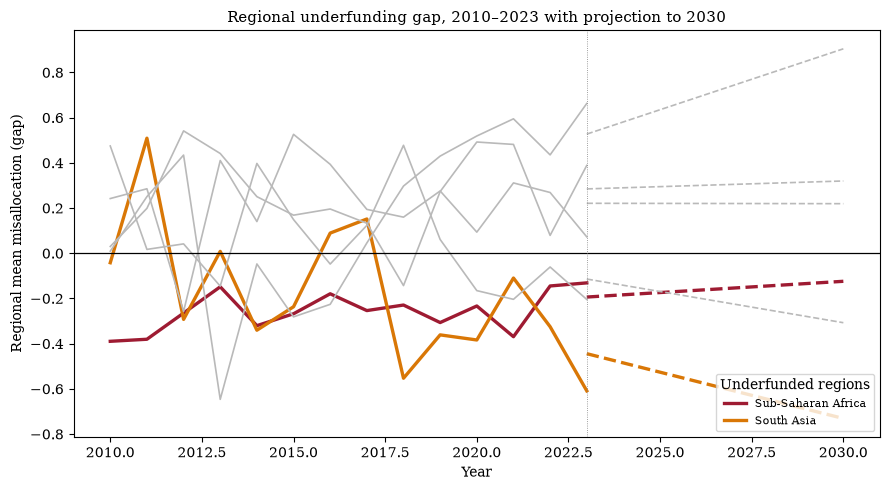


saved: /Users/sanjogkadayat/climate_adaptation_capstone/data/processed/regional_gap_trend.csv


In [7]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
FIG_DIR = root / "figures"; FIG_DIR.mkdir(exist_ok=True)

REGIONS = ["Sub-Saharan Africa", "South Asia", "Latin America & Caribbean",
           "Middle East & North Africa", "Europe & Central Asia", "East Asia & Pacific"]

# residual (gap) series with region attached; mean gap per region-year
gap = pd.read_csv(root / "data" / "processed" / "model_scored.csv")[["iso3", "year", "misallocation_score"]]
gap = gap.merge(cinfo[["iso3", "region"]], on="iso3", how="left")
rg = gap.groupby(["region", "year"])["misallocation_score"].mean().reset_index()

fits, rows = {}, []
for reg in REGIONS:
    d = rg[rg.region == reg]
    r = stats.linregress(d["year"], d["misallocation_score"]); fits[reg] = r
    g23, g30 = r.intercept + r.slope * 2023, r.intercept + r.slope * 2030
    rows.append(dict(region=reg, slope=r.slope, trend_p=r.pvalue, gap_2023=g23, gap_2030=g30,
                     status=("closing" if g23 * r.slope < 0 else "widening" if g23 * r.slope > 0 else "flat")))
regtrend = pd.DataFrame(rows)
print(regtrend.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
emph = {"Sub-Saharan Africa": "#9e1b32", "South Asia": "#d97706"}
for reg in REGIONS:
    d = rg[rg.region == reg]; r = fits[reg]
    c = emph.get(reg, "#b9b9b9"); lw = 2.4 if reg in emph else 1.2
    ax.plot(d["year"], d["misallocation_score"], color=c, lw=lw, label=reg if reg in emph else None)
    fx = np.array([2023, 2030]); ax.plot(fx, r.intercept + r.slope * fx, color=c, lw=lw, ls="--")
ax.axhline(0, color="black", lw=0.9); ax.axvline(2023, color="gray", lw=0.6, ls=":")
ax.set_xlabel("Year"); ax.set_ylabel("Regional mean misallocation (gap)")
ax.set_title("Regional underfunding gap, 2010–2023 with projection to 2030", fontsize=11)
ax.legend(loc="lower right", fontsize=8, title="Underfunded regions")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig05_regional_gap_projection.png", dpi=140); plt.show()

regtrend.to_csv(root / "data" / "processed" / "regional_gap_trend.csv", index=False)
print("\nsaved:", root / "data" / "processed" / "regional_gap_trend.csv")

### Step 3b — Robustness of the underfunded-region trajectories

Because the South Asia trajectory rests on only nine countries, a volatile series, and a pronounced
2023 decline, its statistically significant widening is checked for sensitivity before being reported.
Three diagnostics are applied to both underfunded regions: a Theil-Sen slope, which is robust to
outlier years; a refit excluding the 2023 endpoint; and a count of member countries whose own gap is
deepening. A trend that holds across the ordinary-least-squares slope, the Theil-Sen slope, and the
refit, and that reflects a broad share of member countries rather than one or two, can be reported
with confidence, whereas a trend that collapses when 2023 is removed is treated as endpoint driven.

In [8]:
for reg in ["Sub-Saharan Africa", "South Asia"]:
    d = rg[rg.region == reg].sort_values("year")
    ols  = stats.linregress(d["year"], d["misallocation_score"])
    ts   = stats.theilslopes(d["misallocation_score"].values, d["year"].values)
    d2   = d[d["year"] < 2023]
    ols2 = stats.linregress(d2["year"], d2["misallocation_score"])
    print(f"{reg}:")
    print(f"   OLS slope {ols.slope:+.4f} (p={ols.pvalue:.3f}) | "
          f"Theil-Sen {ts[0]:+.4f} | OLS without 2023 {ols2.slope:+.4f}")
    members = gap[gap.region == reg]
    slopes = {iso: stats.linregress(g["year"], g["misallocation_score"]).slope
              for iso, g in members.groupby("iso3") if g["year"].nunique() >= 5}
    deepening = sum(1 for s in slopes.values() if s < 0)
    print(f"   member countries with deepening gap (negative slope): {deepening} of {len(slopes)}")

Sub-Saharan Africa:
   OLS slope +0.0100 (p=0.086) | Theil-Sen +0.0129 | OLS without 2023 +0.0075
   member countries with deepening gap (negative slope): 20 of 45
South Asia:
   OLS slope -0.0409 (p=0.034) | Theil-Sen -0.0355 | OLS without 2023 -0.0346
   member countries with deepening gap (negative slope): 5 of 9


The regional projection reveals a divergence between the two underfunded regions. Sub-Saharan Africa's
gap is closing, narrowing from approximately −0.19 in 2023 toward −0.12 by 2030, a direction that holds
across the ordinary-least-squares and Theil-Sen slopes and survives removal of the 2023 endpoint,
though the trend is only marginally significant (p = 0.086) and a modest majority of member countries,
twenty-five of forty-five, are improving. South Asia, by contrast, is widening significantly: its gap
deepens from approximately −0.44 in 2023 toward a projected −0.73 by 2030 (p = 0.034), and the result
is robust, with the Theil-Sen slope and the refit excluding 2023 both confirming the direction and a
majority of the nine member countries individually deepening. The post-Paris improvement in
vulnerability-alignment therefore appears to be reaching Sub-Saharan Africa, the largest underfunded
region, while South Asia, home to densely populated and highly vulnerable countries, is falling further
behind and emerges as the priority that current trajectories would leave most exposed. As with all
projections here, the extrapolation to 2030 assumes the historical trend continues and is illustrative
rather than predictive.